# MSCS 634 – Advanced Big Data and Data Mining
## Lab 6: Frequent Itemset Mining and Association Rule Analysis

**Student:** Anna Levinskaia  
**Course:** MSCS 634 – Advanced Big Data and Data Mining  
**Assignment:** Lab 6 – Apriori, FP-Growth, and Association Rules


## Lab Purpose

The purpose of this lab is to perform market basket analysis using the **Apriori** and **FP-Growth** algorithms. The UCI Online Retail dataset is cleaned and converted into item-level transactions. Frequent itemsets and association rules are then evaluated using support, confidence, and lift.

**Dataset:** UCI Machine Learning Repository – Online Retail  
**Official source:** https://archive.ics.uci.edu/dataset/352/online+retail

The full dataset is loaded first. France is selected for the mining portion because it provides enough transactions for useful patterns while keeping Apriori execution manageable in a regular Jupyter environment.


## Step 1: Data Preparation and Exploration

In [1]:
# Import required libraries
from pathlib import Path
from collections import Counter
from itertools import combinations
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

DATA_URL = (
    "https://raw.githubusercontent.com/databricks/"
    "Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv"
)
LOCAL_FILE = Path("data/online-retail-dataset.csv")

# Use the local file when it exists; otherwise download the public CSV mirror.
if LOCAL_FILE.exists():
    retail = pd.read_csv(LOCAL_FILE, encoding="ISO-8859-1")
    print(f"Loaded local file: {LOCAL_FILE}")
else:
    retail = pd.read_csv(DATA_URL, encoding="ISO-8859-1")
    print("Downloaded the Online Retail dataset.")

print("Dataset shape:", retail.shape)
display(retail.head())


Loaded local file: data/online-retail-dataset.csv
Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
# Examine the structure and descriptive statistics
retail.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [3]:
display(retail.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Check missing values and duplicate rows
quality_summary = pd.DataFrame({
    "Missing Values": retail.isnull().sum(),
    "Data Type": retail.dtypes.astype(str)
})

display(quality_summary)
print("Duplicate rows:", retail.duplicated().sum())


,Missing Values,Data Type
InvoiceNo,0,object
StockCode,0,object
Description,1454,object
Quantity,0,int64
InvoiceDate,0,object
UnitPrice,0,float64
CustomerID,135080,float64
Country,0,object


Duplicate rows: 5268


In [5]:
# Clean the dataset
clean = retail.copy()
clean["InvoiceNo"] = clean["InvoiceNo"].astype(str)
clean["StockCode"] = clean["StockCode"].astype(str).str.strip()
clean["Description"] = clean["Description"].astype("string").str.strip()
clean["InvoiceDate"] = pd.to_datetime(clean["InvoiceDate"], errors="coerce")

rows_before = len(clean)

# Remove missing product descriptions, duplicates, cancellations, returns, and invalid prices.
clean = clean.dropna(subset=["InvoiceNo", "StockCode", "Description", "InvoiceDate"])
clean = clean.drop_duplicates()
clean = clean[~clean["InvoiceNo"].str.upper().str.startswith("C")]
clean = clean[(clean["Quantity"] > 0) & (clean["UnitPrice"] > 0)]
clean = clean[clean["Description"].str.len() > 0]

# Remove service or administrative lines that are not normal products.
service_codes = {"POST", "DOT", "M", "D", "C2", "BANK CHARGES"}
service_names = {"POSTAGE", "DOTCOM POSTAGE", "CARRIAGE", "MANUAL", "BANK CHARGES"}
clean = clean[~clean["StockCode"].isin(service_codes)]
clean = clean[~clean["Description"].str.upper().isin(service_names)]

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {len(clean):,}")
print(f"Rows removed:         {rows_before - len(clean):,}")
print(f"Unique invoices:      {clean['InvoiceNo'].nunique():,}")
print(f"Unique products:      {clean['Description'].nunique():,}")
print(f"Countries:            {clean['Country'].nunique():,}")


Rows before cleaning: 541,909
Rows after cleaning:  522,576
Rows removed:         19,333
Unique invoices:      19,778
Unique products:      4,010
Countries:            38


In [6]:
# Select France transactions for market basket analysis.
# This subset is commonly used for manageable association-rule demonstrations.
france = clean[clean["Country"] == "France"].copy()

print("France item-level rows:", len(france))
print("France invoices:", france["InvoiceNo"].nunique())
print("France unique products:", france["Description"].nunique())
display(france.head())


France item-level rows: 8085
France invoices: 382
France unique products: 1560


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France


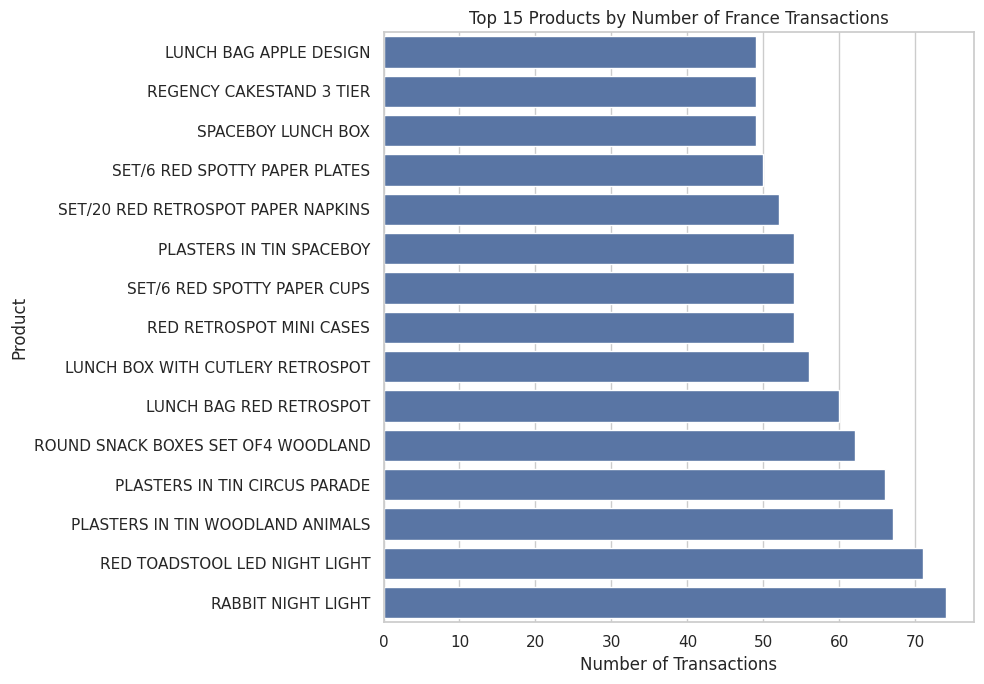

In [7]:
# Visualize the 15 most frequently purchased products by transaction count.
item_frequency = (
    france.drop_duplicates(["InvoiceNo", "Description"])["Description"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 7))
sns.barplot(x=item_frequency.values, y=item_frequency.index, color="C0")
plt.title("Top 15 Products by Number of France Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


In [8]:
# Create a transaction-product basket using True/False values.
basket = (
    france.assign(Present=True)
    .drop_duplicates(["InvoiceNo", "Description"])
    .pivot(index="InvoiceNo", columns="Description", values="Present")
    .fillna(False)
    .astype(bool)
)

print("Basket shape:", basket.shape)
display(basket.iloc[:5, :10])


Basket shape: (382, 1560)


/tmp/ipykernel_1179/3169310822.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND
InvoiceNo,,,,,,,,,,
536370,False,False,False,False,False,False,False,False,False,False
536852,False,False,False,False,False,False,False,False,False,False
536974,False,False,False,False,False,False,False,False,False,False
537065,False,False,False,False,False,False,False,False,False,False
537463,False,False,False,False,False,False,False,False,False,False


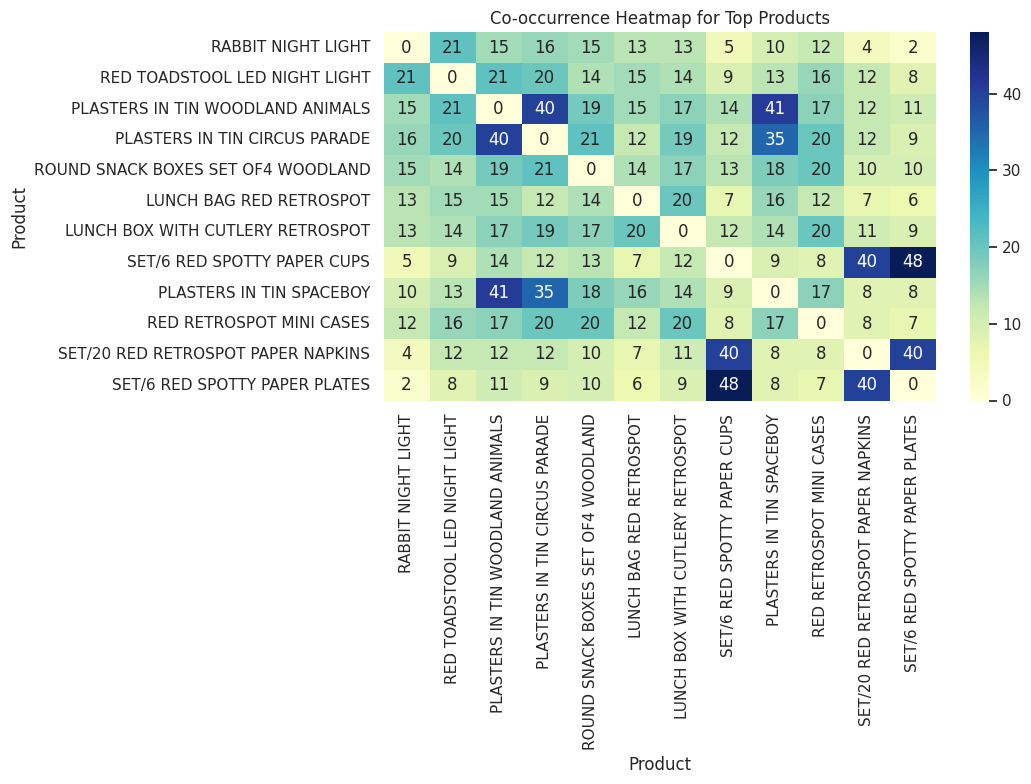

In [9]:
# Heatmap of item co-occurrence for the 12 most common products.
top_items = basket.sum().sort_values(ascending=False).head(12).index
cooccurrence = basket[top_items].astype(int).T.dot(basket[top_items].astype(int))

# Remove diagonal values so the heatmap focuses on item pairs.
np.fill_diagonal(cooccurrence.values, 0)

plt.figure(figsize=(11, 8))
sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Co-occurrence Heatmap for Top Products")
plt.xlabel("Product")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


### Transaction Preparation

A support threshold of **5%** is used. This means that an itemset must appear in at least 5% of the selected transactions. Products below this minimum frequency are removed before mining to reduce unnecessary candidates. Itemsets are limited to a maximum length of four to keep the analysis understandable and efficient.


In [10]:
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.60
MAX_ITEMSET_LENGTH = 4

# Convert each invoice into a set of unique product descriptions.
raw_transactions = (
    france.groupby("InvoiceNo")["Description"]
    .apply(lambda values: set(values))
    .tolist()
)

minimum_count = math.ceil(MIN_SUPPORT * len(raw_transactions))
product_counts = Counter(item for transaction in raw_transactions for item in transaction)
frequent_single_items = {
    item for item, count in product_counts.items() if count >= minimum_count
}

# Keep only products that can satisfy the minimum support threshold.
transactions = [transaction & frequent_single_items for transaction in raw_transactions]
transactions = [transaction for transaction in transactions if transaction]

print("Original France transactions:", len(raw_transactions))
print("Transactions used for mining:", len(transactions))
print("Minimum transaction count:", minimum_count)
print("Products meeting minimum support:", len(frequent_single_items))


Original France transactions: 382
Transactions used for mining: 339
Minimum transaction count: 20
Products meeting minimum support: 76


## Step 2: Frequent Itemset Mining Using Apriori

In [11]:
def apriori(transactions, min_support=0.05, max_len=4):
    """Find frequent itemsets using the Apriori candidate-generation method."""
    transaction_count = len(transactions)
    min_count = math.ceil(min_support * transaction_count)

    one_item_counts = Counter(item for transaction in transactions for item in transaction)
    current_level = {
        frozenset([item]): count
        for item, count in one_item_counts.items()
        if count >= min_count
    }
    all_frequent = dict(current_level)

    itemset_size = 2
    while current_level and itemset_size <= max_len:
        previous_itemsets = list(current_level.keys())
        previous_set = set(previous_itemsets)
        candidates = set()

        # Join frequent itemsets from the previous level.
        for left, right in combinations(previous_itemsets, 2):
            candidate = left | right
            if len(candidate) != itemset_size:
                continue

            # Apriori pruning: every subset must also be frequent.
            all_subsets_frequent = all(
                frozenset(subset) in previous_set
                for subset in combinations(candidate, itemset_size - 1)
            )
            if all_subsets_frequent:
                candidates.add(candidate)

        candidate_counts = Counter()
        for transaction in transactions:
            for candidate in candidates:
                if candidate.issubset(transaction):
                    candidate_counts[candidate] += 1

        current_level = {
            candidate: count
            for candidate, count in candidate_counts.items()
            if count >= min_count
        }
        all_frequent.update(current_level)
        itemset_size += 1

    result = pd.DataFrame([
        {
            "support": count / transaction_count,
            "itemsets": itemset,
            "itemset_length": len(itemset),
            "transaction_count": count,
        }
        for itemset, count in all_frequent.items()
    ])

    return result.sort_values(
        ["support", "itemset_length"], ascending=[False, True]
    ).reset_index(drop=True)


def readable_itemset(itemset):
    return ", ".join(sorted(itemset))


start = time.perf_counter()
apriori_itemsets = apriori(
    transactions,
    min_support=MIN_SUPPORT,
    max_len=MAX_ITEMSET_LENGTH,
)
apriori_time = time.perf_counter() - start

apriori_display = apriori_itemsets.copy()
apriori_display["itemsets"] = apriori_display["itemsets"].apply(readable_itemset)

print(f"Apriori execution time: {apriori_time:.4f} seconds")
print("Frequent itemsets found:", len(apriori_itemsets))
display(apriori_display.head(20))


Apriori execution time: 0.0555 seconds
Frequent itemsets found: 143


,support,itemsets,itemset_length,transaction_count
0,0.218289,RABBIT NIGHT LIGHT,1,74
1,0.209440,RED TOADSTOOL LED NIGHT LIGHT,1,71
2,0.197640,PLASTERS IN TIN WOODLAND ANIMALS,1,67
3,0.194690,PLASTERS IN TIN CIRCUS PARADE,1,66
4,0.182891,ROUND SNACK BOXES SET OF4 WOODLAND,1,62
5,0.176991,LUNCH BAG RED RETROSPOT,1,60
6,0.165192,LUNCH BOX WITH CUTLERY RETROSPOT,1,56
7,0.159292,RED RETROSPOT MINI CASES,1,54
8,0.159292,PLASTERS IN TIN SPACEBOY,1,54
9,0.159292,SET/6 RED SPOTTY PAPER CUPS,1,54


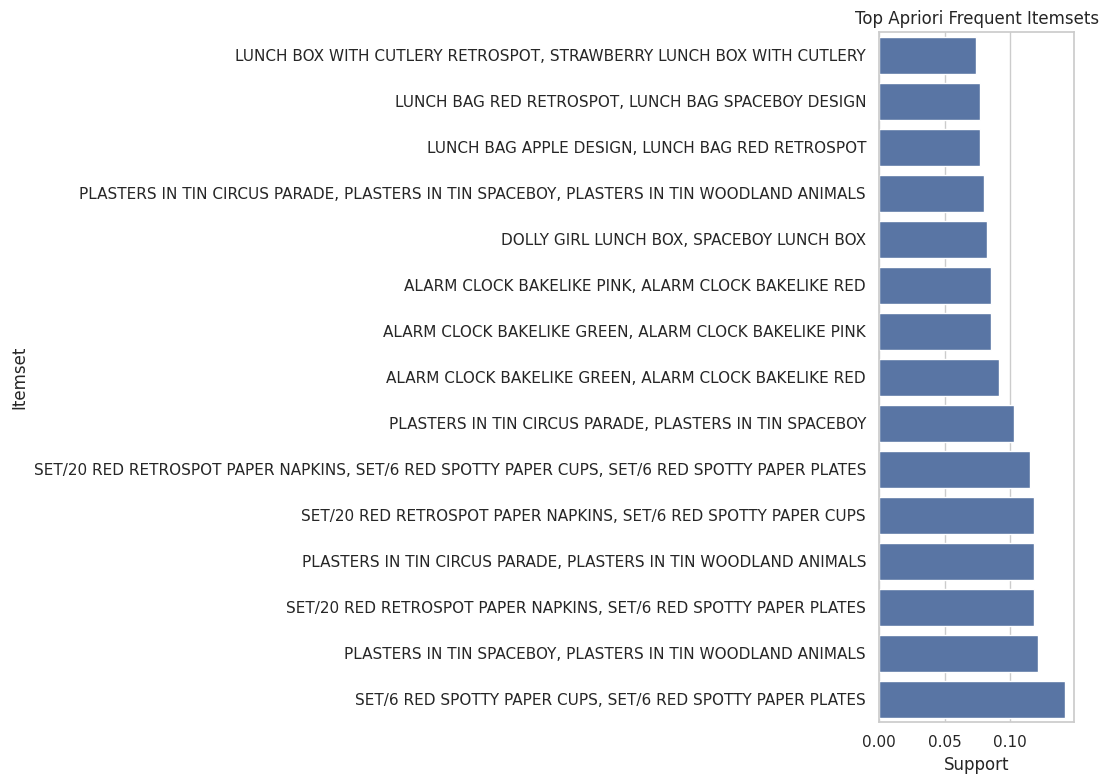

In [12]:
# Visualize the most frequent multi-item sets from Apriori.
top_apriori = apriori_itemsets[apriori_itemsets["itemset_length"] >= 2].head(15).copy()
top_apriori["label"] = top_apriori["itemsets"].apply(readable_itemset)
top_apriori = top_apriori.sort_values("support")

plt.figure(figsize=(11, 8))
sns.barplot(data=top_apriori, x="support", y="label", color="C0")
plt.title("Top Apriori Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.tight_layout()
plt.show()


## Step 3: Frequent Itemset Mining Using FP-Growth

In [13]:
class FPNode:
    """A node in an FP-tree."""

    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.link = None


def build_fp_tree(weighted_transactions, min_count):
    """Build an FP-tree and header table from weighted transactions."""
    item_counts = Counter()
    for items, count in weighted_transactions:
        for item in items:
            item_counts[item] += count

    item_counts = {
        item: count for item, count in item_counts.items() if count >= min_count
    }
    if not item_counts:
        return None, None

    header = {item: [count, None] for item, count in item_counts.items()}
    root = FPNode(item=None, count=0, parent=None)

    for items, count in weighted_transactions:
        ordered_items = [item for item in items if item in item_counts]
        ordered_items.sort(key=lambda item: (-item_counts[item], str(item)))

        current = root
        for item in ordered_items:
            if item in current.children:
                current.children[item].count += count
            else:
                new_node = FPNode(item=item, count=count, parent=current)
                current.children[item] = new_node

                if header[item][1] is None:
                    header[item][1] = new_node
                else:
                    linked_node = header[item][1]
                    while linked_node.link is not None:
                        linked_node = linked_node.link
                    linked_node.link = new_node

            current = current.children[item]

    return root, header


def find_prefix_paths(item, header):
    """Return conditional prefix paths for an item."""
    paths = []
    node = header[item][1]

    while node is not None:
        path = []
        parent = node.parent
        while parent is not None and parent.item is not None:
            path.append(parent.item)
            parent = parent.parent

        if path:
            paths.append((path, node.count))
        node = node.link

    return paths


def mine_fp_tree(header, min_count, prefix, output, max_len):
    """Recursively mine an FP-tree."""
    ordered_header = sorted(header.items(), key=lambda pair: (pair[1][0], str(pair[0])))

    for item, (support_count, _) in ordered_header:
        new_itemset = prefix | frozenset([item])
        output[new_itemset] = support_count

        if len(new_itemset) >= max_len:
            continue

        conditional_paths = find_prefix_paths(item, header)
        _, conditional_header = build_fp_tree(conditional_paths, min_count)

        if conditional_header:
            mine_fp_tree(
                conditional_header,
                min_count,
                new_itemset,
                output,
                max_len,
            )


def fp_growth(transactions, min_support=0.05, max_len=4):
    """Find frequent itemsets using an FP-tree."""
    transaction_count = len(transactions)
    min_count = math.ceil(min_support * transaction_count)
    weighted_transactions = [(list(transaction), 1) for transaction in transactions]

    _, header = build_fp_tree(weighted_transactions, min_count)
    frequent_patterns = {}

    if header:
        mine_fp_tree(
            header,
            min_count,
            frozenset(),
            frequent_patterns,
            max_len,
        )

    result = pd.DataFrame([
        {
            "support": count / transaction_count,
            "itemsets": itemset,
            "itemset_length": len(itemset),
            "transaction_count": count,
        }
        for itemset, count in frequent_patterns.items()
    ])

    return result.sort_values(
        ["support", "itemset_length"], ascending=[False, True]
    ).reset_index(drop=True)


start = time.perf_counter()
fp_itemsets = fp_growth(
    transactions,
    min_support=MIN_SUPPORT,
    max_len=MAX_ITEMSET_LENGTH,
)
fp_time = time.perf_counter() - start

fp_display = fp_itemsets.copy()
fp_display["itemsets"] = fp_display["itemsets"].apply(readable_itemset)

print(f"FP-Growth execution time: {fp_time:.4f} seconds")
print("Frequent itemsets found:", len(fp_itemsets))
display(fp_display.head(20))


FP-Growth execution time: 0.0097 seconds
Frequent itemsets found: 143


,support,itemsets,itemset_length,transaction_count
0,0.218289,RABBIT NIGHT LIGHT,1,74
1,0.209440,RED TOADSTOOL LED NIGHT LIGHT,1,71
2,0.197640,PLASTERS IN TIN WOODLAND ANIMALS,1,67
3,0.194690,PLASTERS IN TIN CIRCUS PARADE,1,66
4,0.182891,ROUND SNACK BOXES SET OF4 WOODLAND,1,62
5,0.176991,LUNCH BAG RED RETROSPOT,1,60
6,0.165192,LUNCH BOX WITH CUTLERY RETROSPOT,1,56
7,0.159292,PLASTERS IN TIN SPACEBOY,1,54
8,0.159292,RED RETROSPOT MINI CASES,1,54
9,0.159292,SET/6 RED SPOTTY PAPER CUPS,1,54


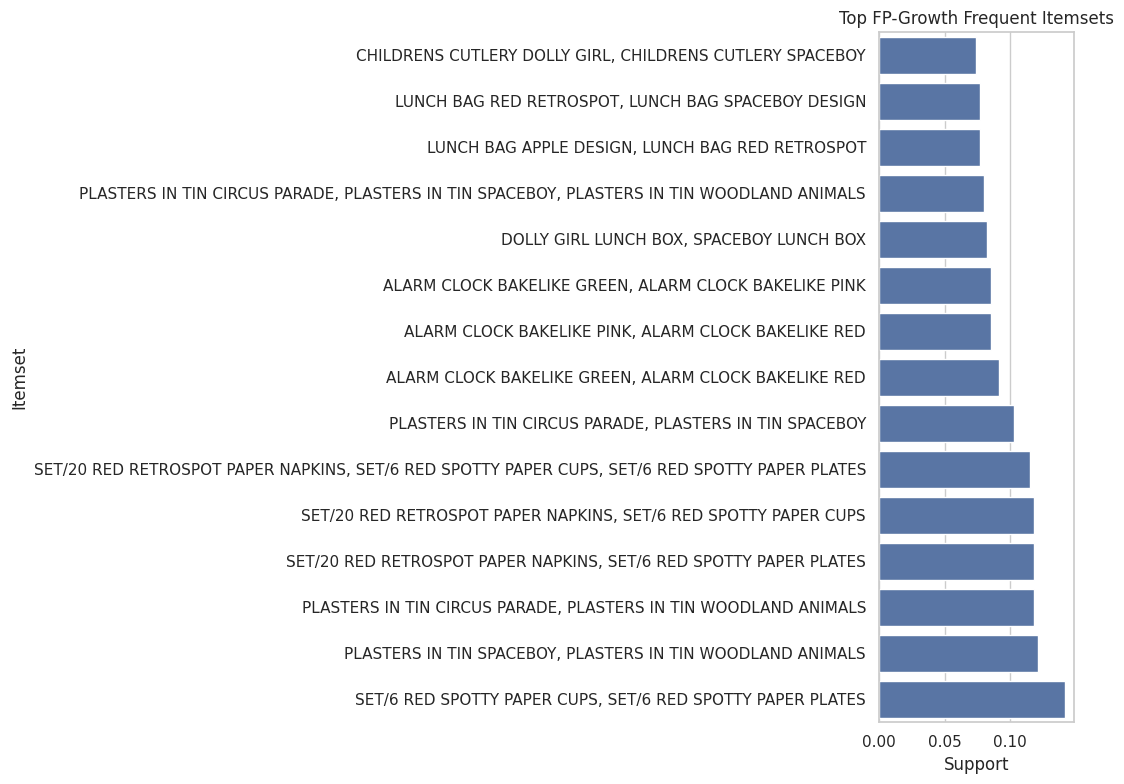

In [14]:
# Visualize the most frequent multi-item sets from FP-Growth.
top_fp = fp_itemsets[fp_itemsets["itemset_length"] >= 2].head(15).copy()
top_fp["label"] = top_fp["itemsets"].apply(readable_itemset)
top_fp = top_fp.sort_values("support")

plt.figure(figsize=(11, 8))
sns.barplot(data=top_fp, x="support", y="label", color="C0")
plt.title("Top FP-Growth Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.tight_layout()
plt.show()


Same itemsets: True
Maximum support difference: 0.0


,Algorithm,Execution Time (seconds),Frequent Itemsets
0,Apriori,0.055497,143
1,FP-Growth,0.009667,143


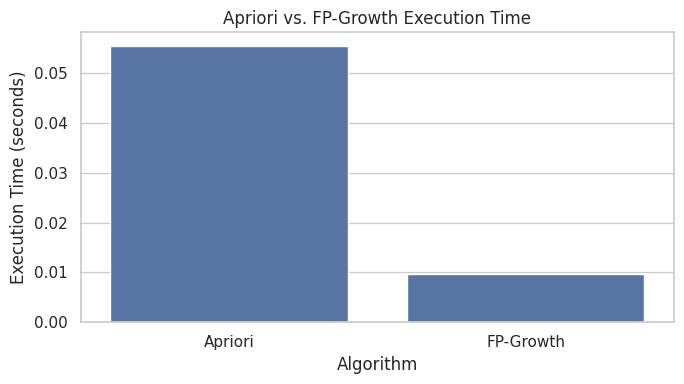

In [15]:
# Confirm that both algorithms found the same itemsets and supports.
apriori_support = dict(zip(apriori_itemsets["itemsets"], apriori_itemsets["support"]))
fp_support = dict(zip(fp_itemsets["itemsets"], fp_itemsets["support"]))

same_itemsets = set(apriori_support) == set(fp_support)
maximum_support_difference = max(
    abs(apriori_support[itemset] - fp_support[itemset])
    for itemset in apriori_support
)

comparison = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Execution Time (seconds)": [apriori_time, fp_time],
    "Frequent Itemsets": [len(apriori_itemsets), len(fp_itemsets)],
})

print("Same itemsets:", same_itemsets)
print("Maximum support difference:", maximum_support_difference)
display(comparison)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="Algorithm", y="Execution Time (seconds)", color="C0")
plt.title("Apriori vs. FP-Growth Execution Time")
plt.tight_layout()
plt.show()


## Step 4: Generating and Analyzing Association Rules

In [16]:
def generate_association_rules(frequent_itemsets, min_confidence=0.60):
    """Generate association rules with support, confidence, and lift."""
    support_lookup = dict(
        zip(frequent_itemsets["itemsets"], frequent_itemsets["support"])
    )
    rules = []

    for itemset, itemset_support in support_lookup.items():
        if len(itemset) < 2:
            continue

        items = list(itemset)
        for antecedent_size in range(1, len(items)):
            for antecedent_tuple in combinations(items, antecedent_size):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                if antecedent not in support_lookup or consequent not in support_lookup:
                    continue

                confidence = itemset_support / support_lookup[antecedent]
                lift = confidence / support_lookup[consequent]

                if confidence >= min_confidence:
                    rules.append({
                        "antecedents": antecedent,
                        "consequents": consequent,
                        "support": itemset_support,
                        "confidence": confidence,
                        "lift": lift,
                    })

    return pd.DataFrame(rules).sort_values(
        ["lift", "confidence", "support"], ascending=False
    ).reset_index(drop=True)


apriori_rules = generate_association_rules(
    apriori_itemsets, min_confidence=MIN_CONFIDENCE
)
fp_rules = generate_association_rules(
    fp_itemsets, min_confidence=MIN_CONFIDENCE
)

rules_display = apriori_rules.copy()
rules_display["antecedents"] = rules_display["antecedents"].apply(readable_itemset)
rules_display["consequents"] = rules_display["consequents"].apply(readable_itemset)

print(f"Confidence threshold: {MIN_CONFIDENCE:.0%}")
print("Apriori rules:", len(apriori_rules))
print("FP-Growth rules:", len(fp_rules))
display(rules_display.head(20))


Confidence threshold: 60%
Apriori rules: 46
FP-Growth rules: 46


,antecedents,consequents,support,confidence,lift
0,PACK OF 6 SKULL PAPER CUPS,PACK OF 6 SKULL PAPER PLATES,0.058997,0.800000,12.327273
1,PACK OF 6 SKULL PAPER PLATES,PACK OF 6 SKULL PAPER CUPS,0.058997,0.909091,12.327273
2,CHILDRENS CUTLERY SPACEBOY,CHILDRENS CUTLERY DOLLY GIRL,0.073746,0.925926,11.210317
3,CHILDRENS CUTLERY DOLLY GIRL,CHILDRENS CUTLERY SPACEBOY,0.073746,0.892857,11.210317
4,"ALARM CLOCK BAKELIKE PINK, ROUND SNACK BOXES SET OF4 WOODLAND",ALARM CLOCK BAKELIKE RED,0.050147,0.894737,8.197724
5,"ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE PINK",ALARM CLOCK BAKELIKE RED,0.073746,0.862069,7.898416
6,ALARM CLOCK BAKELIKE RED,"ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE PINK",0.073746,0.675676,7.898416
7,ALARM CLOCK BAKELIKE GREEN,"ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELIKE RED",0.073746,0.657895,7.690563
8,"ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELIKE RED",ALARM CLOCK BAKELIKE GREEN,0.073746,0.862069,7.690563
9,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.091445,0.837838,7.474395


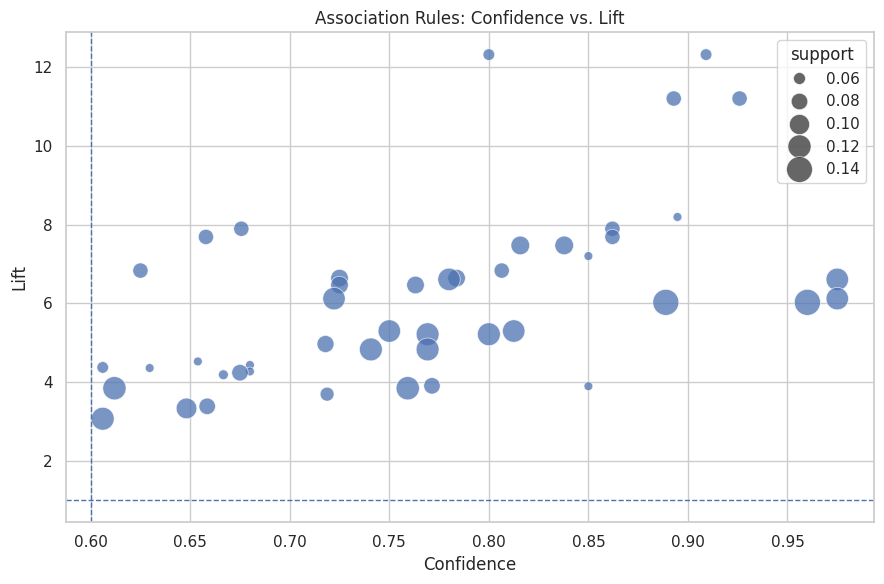

In [17]:
# Scatter plot: confidence versus lift.
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=apriori_rules,
    x="confidence",
    y="lift",
    size="support",
    sizes=(40, 350),
    alpha=0.75,
)
plt.axvline(MIN_CONFIDENCE, linestyle="--", linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Association Rules: Confidence vs. Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.tight_layout()
plt.show()


In [18]:
# Display several strong and easy-to-interpret one-item-to-one-item rules.
simple_rules = apriori_rules[
    (apriori_rules["antecedents"].apply(len) == 1)
    & (apriori_rules["consequents"].apply(len) == 1)
].copy()

simple_rules["antecedents"] = simple_rules["antecedents"].apply(readable_itemset)
simple_rules["consequents"] = simple_rules["consequents"].apply(readable_itemset)

display(simple_rules.head(12))


,antecedents,consequents,support,confidence,lift
0,PACK OF 6 SKULL PAPER CUPS,PACK OF 6 SKULL PAPER PLATES,0.058997,0.800000,12.327273
1,PACK OF 6 SKULL PAPER PLATES,PACK OF 6 SKULL PAPER CUPS,0.058997,0.909091,12.327273
2,CHILDRENS CUTLERY SPACEBOY,CHILDRENS CUTLERY DOLLY GIRL,0.073746,0.925926,11.210317
3,CHILDRENS CUTLERY DOLLY GIRL,CHILDRENS CUTLERY SPACEBOY,0.073746,0.892857,11.210317
9,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.091445,0.837838,7.474395
10,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.091445,0.815789,7.474395
14,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE PINK,0.085546,0.783784,6.642568
15,ALARM CLOCK BAKELIKE PINK,ALARM CLOCK BAKELIKE RED,0.085546,0.725000,6.642568
18,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE PINK,0.085546,0.763158,6.467763
19,ALARM CLOCK BAKELIKE PINK,ALARM CLOCK BAKELIKE GREEN,0.085546,0.725000,6.467763


### Rule Interpretation

- **Paper cup and paper plate products** form strong rules because they are commonly purchased as matching sets.
- **Children's cutlery products** with Spaceboy and Dolly Girl designs have high confidence and lift, showing that customers often buy both related designs together.
- **Baklike alarm clocks** in different colors frequently occur together, suggesting that buyers may purchase multiple colors as a collection or gift set.
- A lift value greater than 1 shows that the item combination appears together more often than would be expected if the products were independent.

These patterns could support product bundling, recommendation systems, and related-item promotions.


## Step 5: Comparative Analysis

In [19]:
speedup = apriori_time / fp_time if fp_time > 0 else np.nan

summary = pd.DataFrame({
    "Measure": [
        "Support threshold",
        "Confidence threshold",
        "Apriori itemsets",
        "FP-Growth itemsets",
        "Association rules",
        "Apriori time (seconds)",
        "FP-Growth time (seconds)",
        "FP-Growth speed advantage",
    ],
    "Result": [
        f"{MIN_SUPPORT:.0%}",
        f"{MIN_CONFIDENCE:.0%}",
        len(apriori_itemsets),
        len(fp_itemsets),
        len(apriori_rules),
        f"{apriori_time:.4f}",
        f"{fp_time:.4f}",
        f"Approximately {speedup:.1f} times faster",
    ],
})

display(summary)


,Measure,Result
0,Support threshold,5%
1,Confidence threshold,60%
2,Apriori itemsets,143
3,FP-Growth itemsets,143
4,Association rules,46
5,Apriori time (seconds),0.0555
6,FP-Growth time (seconds),0.0097
7,FP-Growth speed advantage,Approximately 5.7 times faster


### Comparison and Insights

Both algorithms returned the **same frequent itemsets and support values** because they used the same cleaned transactions and the same support threshold.

**Apriori:**
- Easy to understand and implement.
- Generates candidate itemsets level by level.
- Can become slower when the dataset contains many products or when the support threshold is low.

**FP-Growth:**
- Uses a compact FP-tree instead of repeatedly creating candidate sets.
- Was faster for this dataset.
- Its tree structure is more complex to implement and explain.

**Parameter decisions:**
- A 5% support threshold produced enough useful combinations without creating an excessive number of itemsets.
- A 60% confidence threshold focused the analysis on stronger rules.
- France was selected because running Apriori on every product and every invoice in the full dataset would require substantially more processing.

**Challenges:**
- The original data contained cancellations, returns, missing descriptions, duplicates, and service lines.
- These issues were handled by removing invalid records and keeping only normal product purchases.
- Long product names made visualizations crowded, so only the top results were displayed.

### Final Conclusion

FP-Growth was the more efficient algorithm, while Apriori was easier to follow. The strongest rules involved related product designs and coordinated product sets. These associations could be useful for recommendations, bundles, and targeted promotions.


## References

Chen, D. (2015). *Online Retail* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33

Agrawal, R., & Srikant, R. (1994). Fast algorithms for mining association rules. *Proceedings of the 20th International Conference on Very Large Data Bases*, 487–499.

Han, J., Pei, J., & Yin, Y. (2000). Mining frequent patterns without candidate generation. *Proceedings of the 2000 ACM SIGMOD International Conference on Management of Data*, 1–12.
